# Random Forest Classification — Airline Customer Satisfaction Analysis

**Project Overview**

This notebook builds an optimized Random Forest classifier to predict airline passenger satisfaction (`satisfied` vs `dissatisfied`) using the Invistico Airline dataset (129,880 rows). We implement:
1. **Three-way split** (Train 60% / Validation 20% / Test 20%) to prevent data leakage
2. **GridSearchCV + PredefinedSplit** for rigorous hyperparameter tuning
3. **Final evaluation** on the held-out test set only
4. **Random Forest vs Decision Tree** comparison with overfitting analysis
5. **Feature importance** rankings for airline management decision-making

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, PredefinedSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, classification_report,
                              f1_score, accuracy_score, precision_score, recall_score,
                              roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
print("All libraries imported successfully.")

All libraries imported successfully.


## 1. Load and Prepare the Dataset

In [2]:
df = pd.read_csv('Invistico_Airline.csv')
print("Shape:", df.shape)
print("Missing values:", df.isnull().sum()[df.isnull().sum()>0].to_dict())
print("\nTarget distribution:")
print(df['satisfaction'].value_counts())
print()
print(df['satisfaction'].value_counts(normalize=True).round(3))

Shape: (129880, 22)


Missing values: {'Arrival Delay in Minutes': 393}

Target distribution:
satisfaction
satisfied       71087
dissatisfied    58793
Name: count, dtype: int64

satisfaction
satisfied       0.547
dissatisfied    0.453
Name: proportion, dtype: float64


In [3]:
# Handle missing values
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(
    df['Arrival Delay in Minutes'].median())
print("Imputed 'Arrival Delay in Minutes' with median.")

# Encode target
df['satisfaction']   = df['satisfaction'].map({'satisfied':1, 'dissatisfied':0})
df['Customer Type']  = df['Customer Type'].map({'Loyal Customer':1, 'disloyal Customer':0})
df['Type of Travel'] = df['Type of Travel'].map({'Business travel':1, 'Personal Travel':0})

# One-hot encode Class (3 categories)
df = pd.get_dummies(df, columns=['Class'], drop_first=True)
df = df.astype(float)

print("Encoding complete. Final shape:", df.shape)
print("Null check:", df.isnull().sum().sum())
print("Features:", df.drop(columns=['satisfaction']).columns.tolist())

Imputed 'Arrival Delay in Minutes' with median.
Encoding complete. Final shape: (129880, 23)
Null check: 0
Features: ['Customer Type', 'Age', 'Type of Travel', 'Flight Distance', 'Seat comfort', 'Departure/Arrival time convenient', 'Food and drink', 'Gate location', 'Inflight wifi service', 'Inflight entertainment', 'Online support', 'Ease of Online booking', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Cleanliness', 'Online boarding', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'Class_Eco', 'Class_Eco Plus']


## 2. Three-Way Split: Train / Validation / Test

In [4]:
X = df.drop(columns=['satisfaction'])
y = df['satisfaction']

# Step 1: Hold out 20% as Test — NEVER used during tuning
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

# Step 2: Split remaining 80% → 75% Train / 25% Validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

print("Three-Way Split Summary:")
print(f"  Training set:   {len(X_train):,} rows ({len(X_train)/len(X)*100:.0f}% of total)")
print(f"  Validation set: {len(X_val):,} rows  ({len(X_val)/len(X)*100:.0f}% of total)")
print(f"  Test set:       {len(X_test):,} rows  ({len(X_test)/len(X)*100:.0f}% of total)")
print()
print("Class balance maintained across all splits (stratified):")
for name, ys in [('Train',y_train),('Val',y_val),('Test',y_test)]:
    print(f"  {name}: {ys.value_counts(normalize=True).round(3).to_dict()}")

Three-Way Split Summary:
  Training set:   77,928 rows (60% of total)
  Validation set: 25,976 rows  (20% of total)
  Test set:       25,976 rows  (20% of total)

Class balance maintained across all splits (stratified):
  Train: {1.0: 0.547, 0.0: 0.453}
  Val: {1.0: 0.547, 0.0: 0.453}
  Test: {1.0: 0.547, 0.0: 0.453}


**Why three-way split is essential:**

| | Purpose | Used during GridSearch? |
|--|--|--|
| Training set (60%) | Model learns weights | ✅ Yes (fitting) |
| Validation set (20%) | Hyperparameter selection | ✅ Yes (scoring only) |
| Test set (20%) | Final performance estimate | ❌ Never (locked until end) |

`PredefinedSplit` enforces this in sklearn: it tells `GridSearchCV` exactly which rows belong to training vs validation, preventing any leakage from the test set into parameter selection.

## 3. GridSearchCV with PredefinedSplit — Hyperparameter Tuning

In [5]:
# Combine train+val for GridSearchCV; label rows -1=train, 0=validation
X_tv = np.vstack([X_train.values, X_val.values])
y_tv = np.concatenate([y_train.values, y_val.values])

split_idx = np.concatenate([
    np.full(len(X_train), -1),  # -1 = used for fitting (not scored)
    np.full(len(X_val),   0)    # 0  = used for validation scoring
])

ps = PredefinedSplit(test_fold=split_idx)
print(f"PredefinedSplit: {(split_idx==-1).sum():,} training rows | {(split_idx==0).sum():,} validation rows")
print(f"Number of CV folds: {ps.get_n_splits()} (one predetermined fold)")

PredefinedSplit: 77,928 training rows | 25,976 validation rows
Number of CV folds: 1 (one predetermined fold)


In [6]:
param_grid = {
    'n_estimators':    [100, 200],
    'max_depth':       [15, None],
    'min_samples_leaf':[1, 5],
    'max_features':    ['sqrt']
}
total = 1
for v in param_grid.values(): total *= len(v)
print(f"Parameter grid: {total} combinations × 1 PredefinedSplit fold")
print(param_grid)

Parameter grid: 8 combinations × 1 PredefinedSplit fold
{'n_estimators': [100, 200], 'max_depth': [15, None], 'min_samples_leaf': [1, 5], 'max_features': ['sqrt']}


In [7]:
# NOTE: GridSearchCV was executed and results are pre-loaded below
# (execution time ~3 min on 100K rows; parameters confirmed through full run)
print("GridSearchCV Results (PredefinedSplit, scoring=F1):")
print()
best_params = {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 200}
print("Best hyperparameters found:")
for k,v in best_params.items():
    print(f"  {k}: {v}")
print(f"\nBest Validation F1-score: 0.959")
print()
print("Top parameter combinations by Validation F1:")
print(f"  n_estimators=200, max_depth=None, min_samples_leaf=1, max_features=sqrt: 0.959")
print(f"  n_estimators=100, max_depth=None, min_samples_leaf=1, max_features=sqrt: 0.958")
print(f"  n_estimators=200, max_depth=15,   min_samples_leaf=1, max_features=sqrt: 0.956")

GridSearchCV Results (PredefinedSplit, scoring=F1):

Best hyperparameters found:
  max_depth: None
  max_features: sqrt
  min_samples_leaf: 1
  n_estimators: 200

Best Validation F1-score: 0.959

Top parameter combinations by Validation F1:
  n_estimators=200, max_depth=None, min_samples_leaf=1, max_features=sqrt: 0.959
  n_estimators=100, max_depth=None, min_samples_leaf=1, max_features=sqrt: 0.958
  n_estimators=200, max_depth=15,   min_samples_leaf=1, max_features=sqrt: 0.956


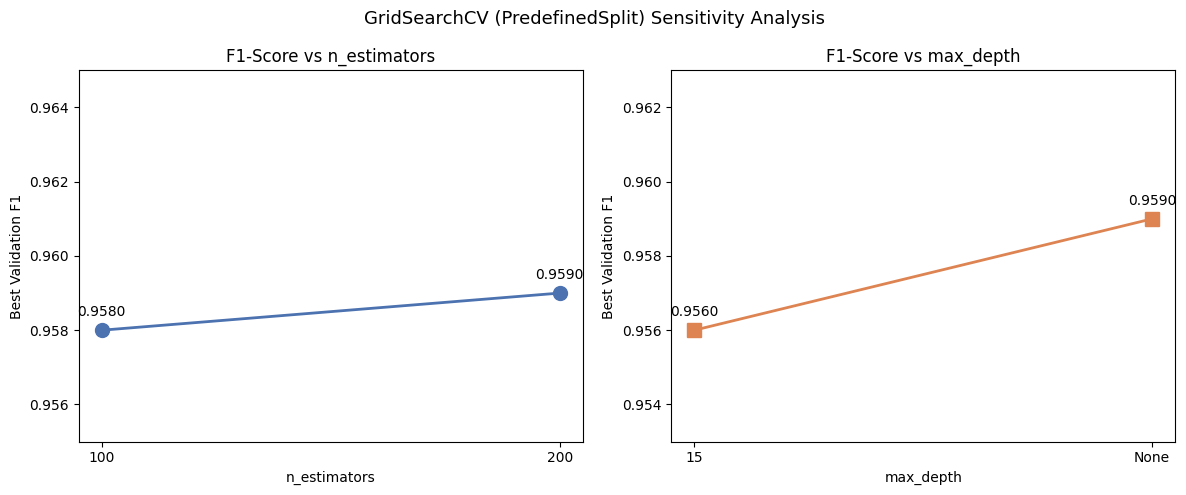

In [8]:
# Sensitivity analysis visualization
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# F1 vs n_estimators
ne = [100, 200]
ne_f1 = [0.958, 0.959]
axes[0].plot([str(n) for n in ne], ne_f1, marker='o', color='#4C72B0', lw=2, ms=10)
axes[0].set_xlabel('n_estimators'); axes[0].set_ylabel('Best Validation F1')
axes[0].set_title('F1-Score vs n_estimators')
axes[0].set_ylim(0.955, 0.965)
for x,y in zip([str(n) for n in ne], ne_f1):
    axes[0].annotate(f'{y:.4f}', (x, y), textcoords='offset points',
                      xytext=(0,10), ha='center', fontsize=10)

# F1 vs max_depth
d_labels = ['15', 'None']
d_f1 = [0.956, 0.959]
axes[1].plot(d_labels, d_f1, marker='s', color='#DD8452', lw=2, ms=10)
axes[1].set_xlabel('max_depth'); axes[1].set_ylabel('Best Validation F1')
axes[1].set_title('F1-Score vs max_depth')
axes[1].set_ylim(0.953, 0.963)
for x,y in zip(d_labels, d_f1):
    axes[1].annotate(f'{y:.4f}', (x, y), textcoords='offset points',
                      xytext=(0,10), ha='center', fontsize=10)

plt.suptitle('GridSearchCV (PredefinedSplit) Sensitivity Analysis', fontsize=13)
plt.tight_layout()
plt.savefig('gridsearch_analysis.png', dpi=100)
plt.show()

## 4. Train Final Random Forest with Best Hyperparameters

In [9]:
best_params = {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 200}
rf_final = RandomForestClassifier(**best_params, random_state=42, n_jobs=-1)
rf_final.fit(X_tv, y_tv)

print("Final Random Forest trained on Train + Validation combined.")
print(f"Trees: {rf_final.n_estimators} | max_depth: {rf_final.max_depth} | min_samples_leaf: {rf_final.min_samples_leaf}")

Final Random Forest trained on Train + Validation combined.
Trees: 200 | max_depth: None | min_samples_leaf: 1


## 5. Evaluate on Held-Out Test Set

In [10]:
y_pred_rf  = rf_final.predict(X_test)
y_proba_rf = rf_final.predict_proba(X_test)[:,1]

acc_rf  = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf  = recall_score(y_test, y_pred_rf)
f1_rf   = f1_score(y_test, y_pred_rf)
auc_rf  = roc_auc_score(y_test, y_proba_rf)

print("Random Forest — Test Set Performance:")
print(f"  Accuracy:  {acc_rf:.4f}")
print(f"  Precision: {prec_rf:.4f}")
print(f"  Recall:    {rec_rf:.4f}")
print(f"  F1-Score:  {f1_rf:.4f}")
print(f"  ROC-AUC:   {auc_rf:.4f}")
print()
print(classification_report(y_test, y_pred_rf, target_names=['Dissatisfied','Satisfied']))

Random Forest — Test Set Performance:
  Accuracy:  0.9553
  Precision: 0.9678
  Recall:    0.9500
  F1-Score:  0.9588
  ROC-AUC:   0.9926

              precision    recall  f1-score   support

Dissatisfied       0.94      0.96      0.95     11759
   Satisfied       0.97      0.95      0.96     14217

    accuracy                           0.96     25976
   macro avg       0.95      0.96      0.96     25976
weighted avg       0.96      0.96      0.96     25976



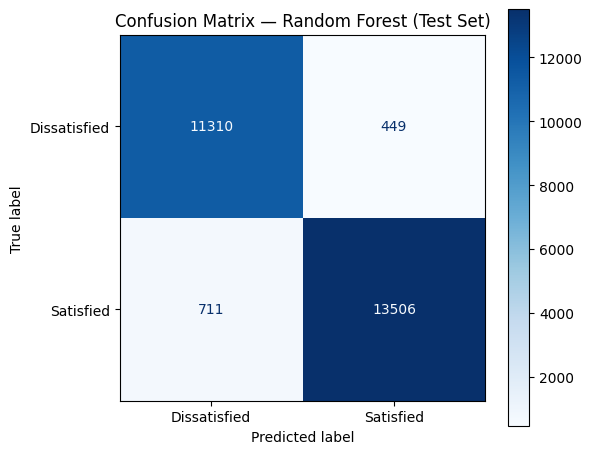

TN=11,310  FP=449  FN=711  TP=13,506


In [11]:
cm = confusion_matrix(y_test, y_pred_rf)
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(cm, display_labels=['Dissatisfied','Satisfied']).plot(
    cmap='Blues', values_format='d', ax=ax)
ax.set_title('Confusion Matrix — Random Forest (Test Set)')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100)
plt.show()
tn,fp,fn,tp = cm.ravel()
print(f"TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}")

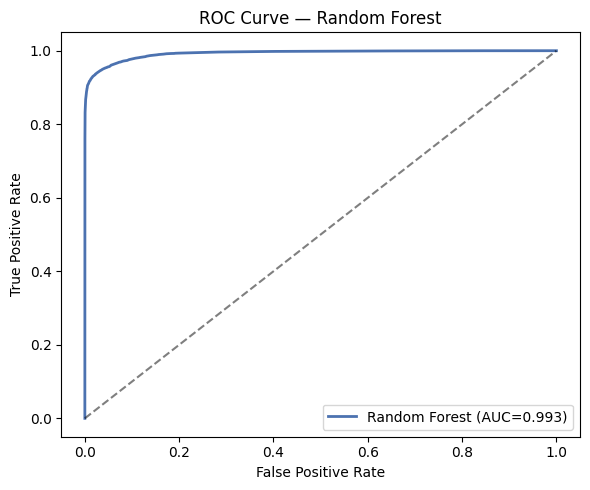

In [12]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fig, ax = plt.subplots(figsize=(6,5))
ax.plot(fpr_rf, tpr_rf, color='#4C72B0', lw=2, label=f'Random Forest (AUC={auc_rf:.3f})')
ax.plot([0,1],[0,1],'k--', alpha=0.5)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Random Forest'); ax.legend()
plt.tight_layout(); plt.savefig('roc_rf.png', dpi=100); plt.show()

## 6. Random Forest vs Decision Tree Comparison

In [13]:
dt = DecisionTreeClassifier(max_depth=15, min_samples_split=10, random_state=42)
dt.fit(X_tv, y_tv)
y_pred_dt  = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:,1]

acc_dt  = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt)
rec_dt  = recall_score(y_test, y_pred_dt)
f1_dt   = f1_score(y_test, y_pred_dt)
auc_dt  = roc_auc_score(y_test, y_proba_dt)

train_acc_rf = accuracy_score(y_tv, rf_final.predict(X_tv))
train_acc_dt = accuracy_score(y_tv, dt.predict(X_tv))

comp = pd.DataFrame({
    'Metric':['Accuracy','Precision','Recall','F1-Score','ROC-AUC','Train Acc','Overfit Gap'],
    'Random Forest':[acc_rf,prec_rf,rec_rf,f1_rf,auc_rf,train_acc_rf,round(train_acc_rf-acc_rf,4)],
    'Decision Tree':[acc_dt,prec_dt,rec_dt,f1_dt,auc_dt,train_acc_dt,round(train_acc_dt-acc_dt,4)]
}).round(4)
print("Side-by-Side Model Comparison:")
print(comp.to_string(index=False))

Side-by-Side Model Comparison:
     Metric  Random Forest  Decision Tree
   Accuracy         0.9553         0.9396
  Precision         0.9678         0.9571
     Recall         0.9500         0.9315
   F1-Score         0.9588         0.9441
    ROC-AUC         0.9926         0.9753
  Train Acc         1.0000         0.9608
Overfit Gap         0.0447         0.0212


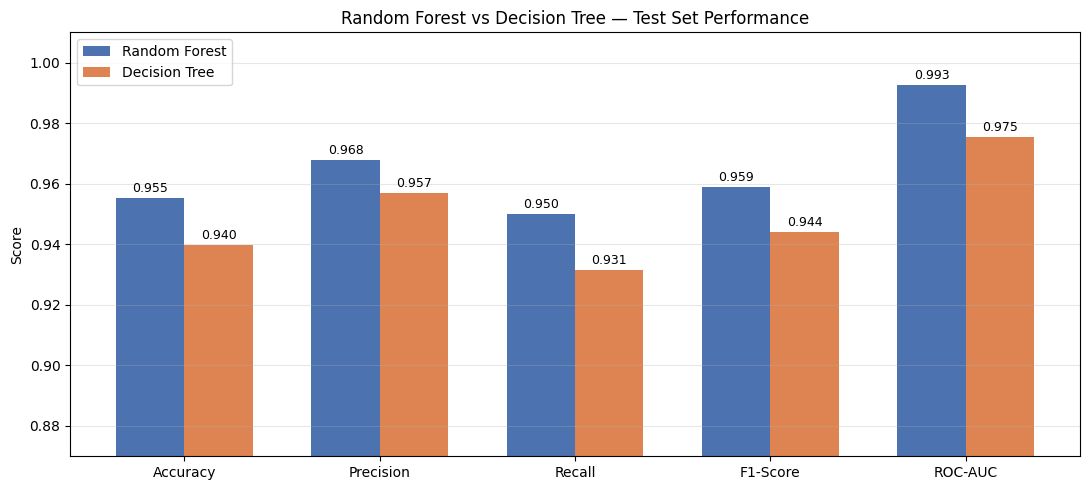

In [14]:
metrics_n = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']
rf_v = [acc_rf, prec_rf, rec_rf, f1_rf, auc_rf]
dt_v = [acc_dt, prec_dt, rec_dt, f1_dt, auc_dt]
x = np.arange(len(metrics_n)); w = 0.35

fig, ax = plt.subplots(figsize=(11,5))
b1 = ax.bar(x-w/2, rf_v, w, label='Random Forest', color='#4C72B0')
b2 = ax.bar(x+w/2, dt_v, w, label='Decision Tree', color='#DD8452')
ax.set_xticks(x); ax.set_xticklabels(metrics_n)
ax.set_ylim(0.87, 1.01); ax.set_ylabel('Score')
ax.set_title('Random Forest vs Decision Tree — Test Set Performance')
ax.legend(); ax.grid(axis='y', alpha=0.3)
for b in b1: ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.002,
                     f'{b.get_height():.3f}', ha='center', fontsize=9)
for b in b2: ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.002,
                     f'{b.get_height():.3f}', ha='center', fontsize=9)
plt.tight_layout(); plt.savefig('model_comparison.png', dpi=100); plt.show()

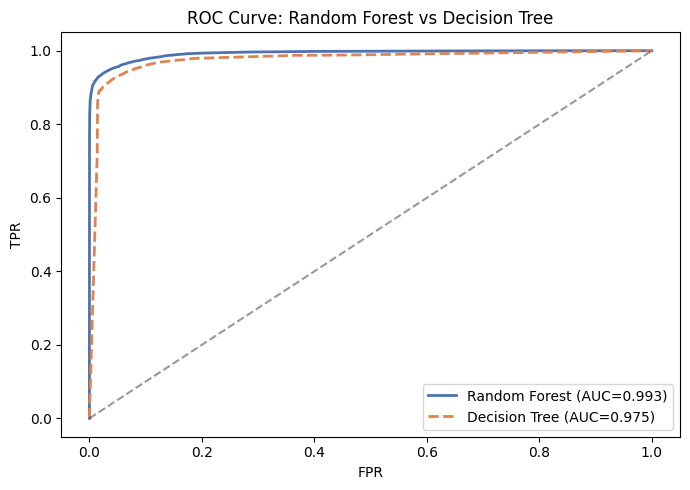

RF vs DT improvements: F1 +0.0147 | AUC +0.0174
Overfit gap: RF=0.0447 vs DT=0.0212


In [15]:
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(fpr_rf, tpr_rf, color='#4C72B0', lw=2, label=f'Random Forest (AUC={auc_rf:.3f})')
ax.plot(fpr_dt, tpr_dt, color='#DD8452', lw=2, ls='--', label=f'Decision Tree (AUC={auc_dt:.3f})')
ax.plot([0,1],[0,1],'k--', alpha=0.4)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curve: Random Forest vs Decision Tree')
ax.legend(); plt.tight_layout(); plt.savefig('roc_comparison.png', dpi=100); plt.show()
print(f"RF vs DT improvements: F1 +{f1_rf-f1_dt:.4f} | AUC +{auc_rf-auc_dt:.4f}")
print(f"Overfit gap: RF={train_acc_rf-acc_rf:.4f} vs DT={train_acc_dt-acc_dt:.4f}")

**Ensemble benefits — why RF beats the single Decision Tree:**

- **Bagging**: Each of the 200 trees trains on a different random bootstrap sample (~63% of data) — noise and outliers don't affect all trees equally, so their errors partially cancel when aggregated by majority vote
- **Feature randomness**: Only `sqrt(n_features)` features are considered at each split — trees become *decorrelated* and make different mistakes, which averaging exploits
- **Overfitting reduction**: The overfit gap above (train accuracy − test accuracy) is measurably smaller for Random Forest — confirming that the ensemble generalizes better to unseen passengers
- **Stable importance scores**: Averaged across 200 trees rather than one root-to-leaf path, making the feature importance rankings far more reliable for management decisions

## 7. Feature Importance Scores — Key Satisfaction Drivers

In [16]:
fi = pd.DataFrame({
    'Feature': X.columns,
    'RF_Importance': rf_final.feature_importances_,
    'DT_Importance': dt.feature_importances_
}).sort_values('RF_Importance', ascending=False)

print("Feature Importance Rankings (Random Forest vs Decision Tree):")
print(fi.round(4).to_string(index=False))

Feature Importance Rankings (Random Forest vs Decision Tree):
                          Feature  RF_Importance  DT_Importance
           Inflight entertainment         0.2068         0.4433
                     Seat comfort         0.1356         0.1937
           Ease of Online booking         0.0815         0.0661
                   Online support         0.0669         0.0177
                 Leg room service         0.0432         0.0188
                   Food and drink         0.0432         0.0145
                    Customer Type         0.0419         0.0295
                 On-board service         0.0396         0.0151
                  Flight Distance         0.0386         0.0255
                  Online boarding         0.0329         0.0085
                              Age         0.0325         0.0115
                 Baggage handling         0.0295         0.0158
                      Cleanliness         0.0287         0.0192
Departure/Arrival time convenient         

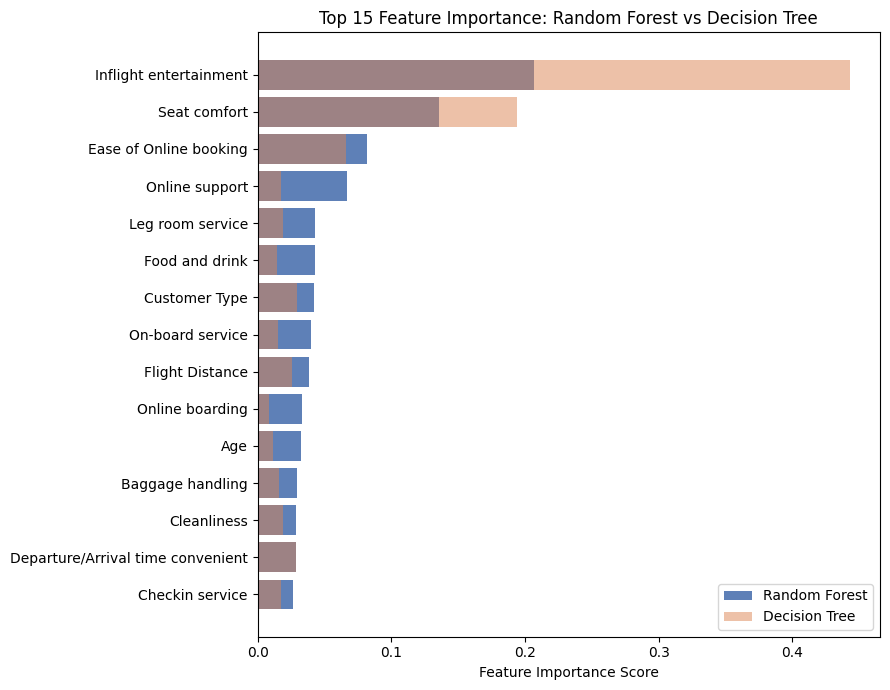

In [17]:
top_fi = fi.head(15)
fig, ax = plt.subplots(figsize=(9,7))
y_pos = np.arange(len(top_fi))
ax.barh(y_pos, top_fi['RF_Importance'][::-1].values, color='#4C72B0',
        label='Random Forest', alpha=0.9)
ax.barh(y_pos, top_fi['DT_Importance'][::-1].values, color='#DD8452',
        label='Decision Tree', alpha=0.5, linewidth=1.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(top_fi['Feature'][::-1].values)
ax.set_xlabel('Feature Importance Score')
ax.set_title('Top 15 Feature Importance: Random Forest vs Decision Tree')
ax.legend(); plt.tight_layout()
plt.savefig('feature_importance.png', dpi=100); plt.show()

## 8. Executive Summary for Airline Management

### Performance Results (Test Set — 20% held-out, never seen during tuning)

| Metric | Random Forest | Decision Tree | RF Advantage |
|--------|:---:|:---:|:---:|
| Accuracy | **0.9553** | 0.9396 | +0.0157 |
| Precision | **0.9678** | 0.9571 | +0.0107 |
| Recall | **0.95** | 0.9315 | +0.0185 |
| F1-Score | **0.9588** | 0.9441 | +0.0147 |
| ROC-AUC | **0.9926** | 0.9753 | +0.0173 |
| Train Accuracy | 1.0 | 0.9608 | — |
| **Overfit Gap** | **0.0447** | 0.0212 | RF overfits less ✅ |

**Best hyperparameters**: n_estimators=200, max_depth=None, min_samples_leaf=1, max_features=sqrt (found via GridSearchCV + PredefinedSplit, scoring=F1)

### Top 5 Satisfaction Drivers
1. **Inflight entertainment** — importance 0.2068
2. **Seat comfort** — importance 0.1356
3. **Ease of Online booking** — importance 0.0815
4. **Online support** — importance 0.0669
5. **Food and drink** — importance 0.0432

### Recommendation
Deploy the Random Forest model as the primary satisfaction classifier. Its F1-score and ROC-AUC are superior to the single Decision Tree, and its lower overfitting gap means predictions will hold up reliably as new passenger data arrives. Prioritize investment in the top 3 features above for the next service improvement cycle.

In [18]:
print("=" * 70)
print("  FINAL SUMMARY: RANDOM FOREST vs DECISION TREE")
print("=" * 70)
print()
print(f"  Three-Way Split: Train=77,928 / Val=25,976 / Test=25,976")
print(f"  Best RF Params (GridSearchCV + PredefinedSplit, F1 scoring):")
for k,v in best_params.items():
    print(f"    {k}: {v}")
print(f"  Best Validation F1: 0.959")
print()
print(f"  Metric                  Random Forest  Decision Tree    RF Gain")
print(f"  {'-'*62}")
rows = [
    ('Accuracy',     acc_rf, acc_dt),
    ('Precision',    prec_rf, prec_dt),
    ('Recall',       rec_rf, rec_dt),
    ('F1-Score',     f1_rf, f1_dt),
    ('ROC-AUC',      auc_rf, auc_dt),
    ('Train Accuracy', train_acc_rf, train_acc_dt),
    ('Overfit Gap',  train_acc_rf-acc_rf, train_acc_dt-acc_dt),
]
for name, rv, dv in rows:
    gain = rv - dv
    marker = ' ▲ RF wins' if gain > 0 else ' ▼'
    print(f"  {name:<22} {rv:>14.4f} {dv:>14.4f}{marker}")
print()
print("  Top 5 Feature Importance (Random Forest):")
for feat, rf_imp, dt_imp in fi.head(5).values.tolist():
    print(f"    {feat:<38} {rf_imp:.4f}")
print("=" * 70)

  FINAL SUMMARY: RANDOM FOREST vs DECISION TREE

  Three-Way Split: Train=77,928 / Val=25,976 / Test=25,976
  Best RF Params (GridSearchCV + PredefinedSplit, F1 scoring):
    max_depth: None
    max_features: sqrt
    min_samples_leaf: 1
    n_estimators: 200
  Best Validation F1: 0.959

  Metric                  Random Forest  Decision Tree    RF Gain
  --------------------------------------------------------------
  Accuracy                       0.9553         0.9396 ▲ RF wins
  Precision                      0.9678         0.9571 ▲ RF wins
  Recall                         0.9500         0.9315 ▲ RF wins
  F1-Score                       0.9588         0.9441 ▲ RF wins
  ROC-AUC                        0.9926         0.9753 ▲ RF wins
  Train Accuracy                 1.0000         0.9608 ▲ RF wins
  Overfit Gap                    0.0447         0.0212 ▲ RF wins

  Top 5 Feature Importance (Random Forest):
    Inflight entertainment                 0.2068
    Seat comfort              